# Python for Healthcare Analytics — Assignment 1
## Exploratory Analysis of Hospital Claims

**AI-use disclosure:** I used Claude (Anthropic) to help develop the code in this notebook, working through the assignment part by part. All outputs were produced by running the code, and the written interpretations are my own.


## Part A — Load & Inspect

**A1. Load the dataset and report its shape.**

In [1]:
import pandas as pd

# Load the claims data directly from the source URL given in the brief
url = ('https://github.com/thousandoaks/Python4DS-I/'
       'raw/main/datasets/HealthcareDataset_PublicRelease.csv')
df = pd.read_csv(url)

print('Shape (rows, columns):', df.shape)

Shape (rows, columns): (52563, 17)


**A2. Column names and dtypes — which date columns are stored as text?**

In [2]:
# Show every column and its data type
print(df.dtypes)

# The three date fields should be datetimes; check whether they are still text
date_fields = ['StartDate', 'EndDate', 'BirthDate']
stored_as_text = [c for c in date_fields
                  if not pd.api.types.is_datetime64_any_dtype(df[c])]
print()
print('Date columns currently stored as text:', stored_as_text)

Id                          int64
MemberName                    str
MemberID                      str
County                        str
MedicalClaim                  str
ClaimItem                   int64
HospitalName                  str
HospitalType                  str
StartDate                     str
EndDate                       str
PrincipalDiagnosisDesc        str
PrincipalDiagnosis            str
RevenueCodeDesc               str
RevenueCode               float64
TypeFlag                      str
BirthDate                     str
TotalExpenses             float64
dtype: object

Date columns currently stored as text: ['StartDate', 'EndDate', 'BirthDate']


*TODO — write 2–4 sentences in your own words: which date columns are stored as text and why they need converting with pd.to_datetime() before date filtering or arithmetic.*

**A3. Missing values per column.**

In [3]:
# Count missing values in each column and name the affected column(s)
missing = df.isna().sum()
print(missing)
print()
print('Columns with missing values:', list(missing[missing > 0].index))

Id                        0
MemberName                0
MemberID                  0
County                    0
MedicalClaim              0
ClaimItem                 0
HospitalName              0
HospitalType              0
StartDate                 0
EndDate                   0
PrincipalDiagnosisDesc    0
PrincipalDiagnosis        0
RevenueCodeDesc           2
RevenueCode               0
TypeFlag                  0
BirthDate                 0
TotalExpenses             0
dtype: int64

Columns with missing values: ['RevenueCodeDesc']


**A4. Summary statistics for TotalExpenses.**

In [4]:
# Summary statistics for the cost variable
df['TotalExpenses'].describe()

count     52563.000000
mean       2735.230373
std        8292.178928
min           0.000000
25%         194.642000
50%         675.262000
75%        2309.265000
max      504533.400000
Name: TotalExpenses, dtype: float64

*TODO — one sentence in your own words: describe the distribution's shape by comparing the mean to the median (what does mean >> median imply about skew?).*

## Part B — Filtering

**Preparation: parse the date columns.** These are needed for the date filter below and the derived columns in Part E.

In [5]:
# Convert the three text date columns to proper datetimes
for col in ['StartDate', 'EndDate', 'BirthDate']:
    df[col] = pd.to_datetime(df[col])

df[['StartDate', 'EndDate', 'BirthDate']].dtypes

StartDate    datetime64[us]
EndDate      datetime64[us]
BirthDate    datetime64[us]
dtype: object

**B1. Emergency (ER) line items only.**

In [6]:
# Single-condition filter: keep only emergency line items
er_items = df[df['TypeFlag'] == 'ER']
print('ER line items:', len(er_items))

ER line items: 23978


**B2. Line items over \$10,000 and their share of total spend.**

In [7]:
# Filter to high-cost line items, then compute their share of all spend
high_cost = df[df['TotalExpenses'] > 10000]
share = high_cost['TotalExpenses'].sum() / df['TotalExpenses'].sum()
print('Line items over $10,000:', len(high_cost))
print(f'Share of total spend: {share:.1%}')

Line items over $10,000: 3090
Share of total spend: 51.1%


*TODO — write 2–4 sentences in your own words: a small number of line items account for what share of spend — what does that say about cost concentration?*

**B3. Compound condition: inpatient line items at rehabilitation centers.**

In [8]:
# Compound filter: both conditions must hold (note the parentheses around each)
rehab_inp = df[(df['TypeFlag'] == 'INP') &
               (df['HospitalType'] == 'REHABILITATION CENTER')]
print('Rows:', len(rehab_inp))
rehab_inp.head()

Rows: 20


,Id,MemberName,MemberID,County,MedicalClaim,ClaimItem,HospitalName,HospitalType,StartDate,EndDate,PrincipalDiagnosisDesc,PrincipalDiagnosis,RevenueCodeDesc,RevenueCode,TypeFlag,BirthDate,TotalExpenses
4664,642704,729c3184,6cf57dc3,ea48569b,d2e1e1dd74879ef7,12,2aabe637,REHABILITATION CENTER,2020-01-04,2020-01-11,Other sequelae of cerebra,I69.398,OTHER THERAPEUTIC SERV,940.0,INP,1952-05-19,41.090
4666,642706,729c3184,6cf57dc3,ea48569b,d2e1e1dd74879ef7,2,2aabe637,REHABILITATION CENTER,2020-01-04,2020-01-11,Other sequelae of cerebra,I69.398,REHAB,128.0,INP,1952-05-19,4674.600
4679,642767,729c3184,6cf57dc3,ea48569b,d2e1e1dd74879ef7,3,2aabe637,REHABILITATION CENTER,2020-01-04,2020-01-11,Other sequelae of cerebra,I69.398,PHARMACY,250.0,INP,1952-05-19,760.368
4680,642768,729c3184,6cf57dc3,ea48569b,d2e1e1dd74879ef7,4,2aabe637,REHABILITATION CENTER,2020-01-04,2020-01-11,Other sequelae of cerebra,I69.398,MEDICAL/SURGICAL SUPPLIES,270.0,INP,1952-05-19,331.226
4681,642769,729c3184,6cf57dc3,ea48569b,d2e1e1dd74879ef7,10,2aabe637,REHABILITATION CENTER,2020-01-04,2020-01-11,Other sequelae of cerebra,I69.398,SPEECH-LANGUAGE PATHOLOGY,440.0,INP,1952-05-19,544.950


**B4. Line items starting in January 2020.**

In [9]:
# Date-based filter on the parsed StartDate column
jan_2020 = df[(df['StartDate'] >= '2020-01-01') & (df['StartDate'] <= '2020-01-31')]
print('Line items starting in January 2020:', len(jan_2020))

Line items starting in January 2020: 6788


## Part C — Group By & Aggregation

**C1. Count, mean and sum of TotalExpenses by TypeFlag.**

In [10]:
# Grouped aggregation on one key with three statistics
by_type = df.groupby('TypeFlag')['TotalExpenses'].agg(['count', 'mean', 'sum'])
by_type

,count,mean,sum
TypeFlag,,,
ER,23978,923.916490,2.215367e+07
INP,28585,4254.617614,1.216182e+08


*TODO — write 2–4 sentences in your own words: which category (INP or ER) costs more per line item on average, and roughly by how much.*

**C2. Five highest-spending counties.**

In [11]:
# Total spend per county, sorted, top five
top_counties = (df.groupby('County')['TotalExpenses']
                  .sum()
                  .sort_values(ascending=False)
                  .head(5))
top_counties

County
02af982d    6.965805e+07
425a37b2    2.389492e+07
fd218584    1.641345e+07
89e38653    8.851130e+06
b021dd12    6.025211e+06
Name: TotalExpenses, dtype: float64

**C3. Ten most frequent principal diagnoses.**

In [12]:
# Frequency count of line items per principal diagnosis
df['PrincipalDiagnosisDesc'].value_counts().head(10)

PrincipalDiagnosisDesc
Other chest pain             2608
Sepsis unspecified organi    2046
Chronic obstructive pulmo    1372
Atherosclerotic heart dis    1241
Hypertensive heart and ch    1126
COVID-19                     1064
Acute kidney failure unsp    1017
Type 2 diabetes mellitus     1011
Non-ST elevation (NSTEMI)     992
Hypertensive heart diseas     972
Name: count, dtype: int64

**C4. Mean TotalExpenses by HospitalType and TypeFlag.**

In [13]:
# Two-key grouping, unstacked into a readable table
mean_by_type = (df.groupby(['HospitalType', 'TypeFlag'])['TotalExpenses']
                  .mean()
                  .unstack()
                  .round(2))
mean_by_type

TypeFlag,ER,INP
HospitalType,,
HOSPITAL,923.92,4254.33
HOSPITAL LONG TERM ACUTE,NaN,5411.28
REHABILITATION CENTER,NaN,1248.30


*Note: the NaN cells are combinations that do not occur in the data — long-term acute and rehabilitation facilities have no ER line items.*

## Part D — Visualization with seaborn

**D1. Histogram of TotalExpenses** (x-axis restricted to 0–5,000 so the shape is visible despite the skew).

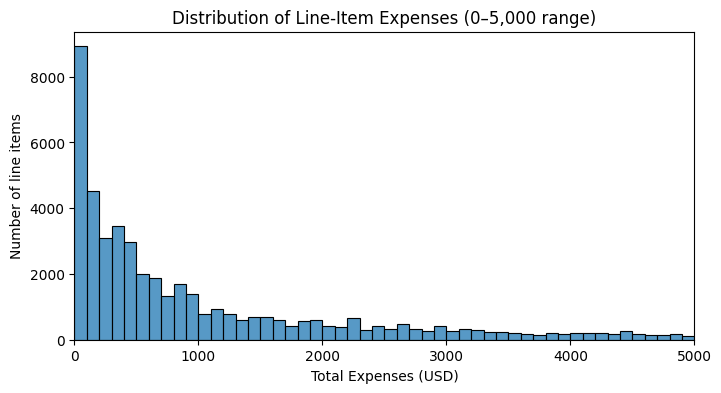

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

# Histogram of the cost variable, restricted to the 0-5,000 range per the brief
plt.figure(figsize=(8, 4))
sns.histplot(data=df, x='TotalExpenses', bins=50, binrange=(0, 5000))
plt.xlim(0, 5000)
plt.title('Distribution of Line-Item Expenses (0–5,000 range)')
plt.xlabel('Total Expenses (USD)')
plt.ylabel('Number of line items')
plt.show()

*TODO — one sentence: describe the shape (where most line items sit, direction of the tail).*

**D2. Boxplot of TotalExpenses by TypeFlag.** A log scale is used on the y-axis so the medians and spread are visible despite extreme outliers.

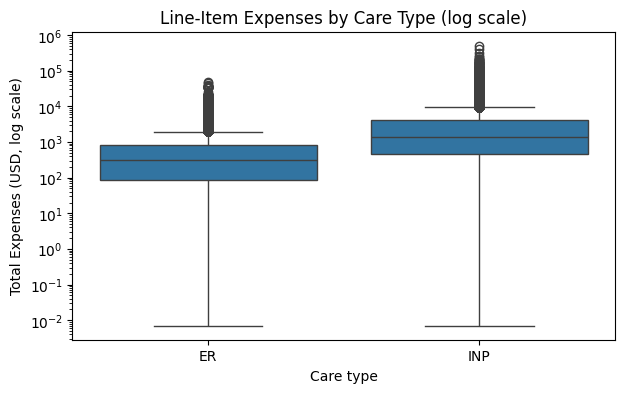

In [15]:
# Boxplot comparing inpatient vs emergency costs; log scale handles the skew
plt.figure(figsize=(7, 4))
sns.boxplot(data=df[df['TotalExpenses'] > 0], x='TypeFlag', y='TotalExpenses')
plt.yscale('log')
plt.title('Line-Item Expenses by Care Type (log scale)')
plt.xlabel('Care type')
plt.ylabel('Total Expenses (USD, log scale)')
plt.show()

Inpatient (INP) line items are both **higher** and **more variable** than emergency (ER) line items. The median INP claim (about \$1,379) is roughly **4.5×** the ER median (about \$307), so a typical inpatient item costs several times more than a typical ER item — the whole distribution is shifted upward, not just the average. INP is also far more spread out: its interquartile range (Q1 \$454 to Q3 \$4,048, about \$3,594 wide) is roughly **4.7×** the ER IQR (Q1 \$83 to Q3 \$842, about \$759 wide), meaning inpatient costs are much less predictable. Both distributions are strongly right-skewed with long tails of high-cost outliers, but INP's tail reaches far higher (a maximum near \$505,000 versus about \$48,000 for ER) — which is why a log scale and the median/IQR describe the data more fairly than the mean.

**D3. Scatterplot: total claim cost vs length of stay.** Line items and stays are at different grains, so we first aggregate to one row per claim (the `LengthOfStay` column is derived formally in Part E; it is computed here so the notebook runs top-to-bottom).

Claims: 3361


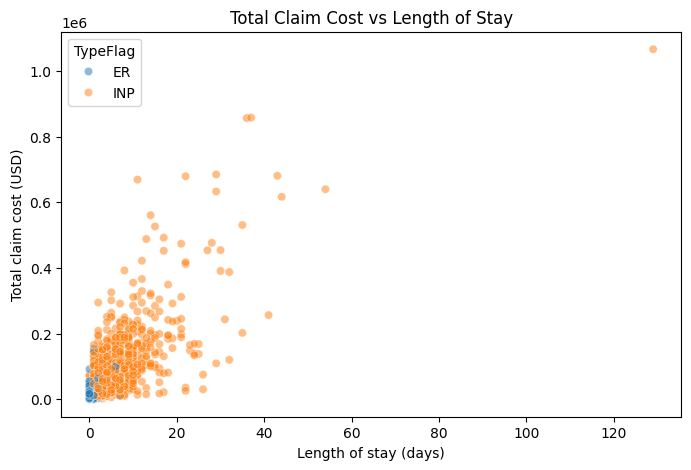

In [16]:
# LengthOfStay in days (formally part of Part E, computed here for run order)
df['LengthOfStay'] = (df['EndDate'] - df['StartDate']).dt.days

# Aggregate to one row per claim: sum the line items, keep the stay length and type
claims = (df.groupby('MedicalClaim')
            .agg(ClaimTotal=('TotalExpenses', 'sum'),
                 LengthOfStay=('LengthOfStay', 'first'),
                 TypeFlag=('TypeFlag', 'first'))
            .reset_index())
print('Claims:', len(claims))

plt.figure(figsize=(8, 5))
sns.scatterplot(data=claims, x='LengthOfStay', y='ClaimTotal',
                hue='TypeFlag', alpha=0.5)
plt.title('Total Claim Cost vs Length of Stay')
plt.xlabel('Length of stay (days)')
plt.ylabel('Total claim cost (USD)')
plt.show()

*TODO — write 2–4 sentences in your own words: describe the relationship you see between stay length and claim cost, and how ER claims differ from INP claims on this plot.*

## Part E — Functions & Derived Columns

**E1. Age in completed years at 2020-12-31.**

In [17]:
# Reusable function: age in completed years at a reference date
def compute_age(birthdate, ref_date):
    """Return age in completed years at ref_date."""
    return (ref_date.year - birthdate.year
            - ((ref_date.month, ref_date.day) < (birthdate.month, birthdate.day)))

ref_date = pd.Timestamp('2020-12-31')
df['Age'] = df['BirthDate'].apply(lambda b: compute_age(b, ref_date))
df['Age'].describe()

count    52563.000000
mean        72.159123
std         12.230098
min         21.000000
25%         67.000000
50%         73.000000
75%         81.000000
max         99.000000
Name: Age, dtype: float64

**E2. LengthOfStay (days) from EndDate − StartDate.** (Created in Part D3 for run order; shown again here.)

In [18]:
# LengthOfStay in whole days
df['LengthOfStay'] = (df['EndDate'] - df['StartDate']).dt.days
df['LengthOfStay'].describe()

count    52563.000000
mean         3.869109
std          6.008744
min          0.000000
25%          1.000000
50%          2.000000
75%          5.000000
max        129.000000
Name: LengthOfStay, dtype: float64

**E3. Age bands.**

In [19]:
# Map each age into a band and count line items per band
def age_band(age):
    """Return the age band for an age in years."""
    if age < 40:
        return '<40'
    elif age < 65:
        return '40–64'
    elif age < 80:
        return '65–79'
    else:
        return '80+'

df['AgeBand'] = df['Age'].apply(age_band)
df['AgeBand'].value_counts()

AgeBand
65–79    27781
80+      14601
40–64     9444
<40        737
Name: count, dtype: int64

**E4. Cost tiers.**

In [20]:
# Assign each line item to a cost tier by value
def cost_tier(x):
    """Return 'Low' (<$500), 'Medium' ($500–4,999) or 'High' (>=$5,000)."""
    if x < 500:
        return 'Low'
    elif x < 5000:
        return 'Medium'
    else:
        return 'High'

df['CostTier'] = df['TotalExpenses'].apply(cost_tier)
df['CostTier'].value_counts()

CostTier
Low       22981
Medium    22948
High       6634
Name: count, dtype: int64

## Part F — Merge

**F1. Load the member reference table and left-join it on MemberID.**

In [21]:
# Load the member reference table from its source URL
member_url = ('https://raw.githubusercontent.com/thousandoaks/'
              'Python4DS-I/refs/heads/main/datasets/MemberReference.csv')
member_ref = pd.read_csv(member_url)
print('Member reference shape:', member_ref.shape)

# Left join keeps every claim line item, adding plan details where they match
merged = df.merge(member_ref, on='MemberID', how='left')
merged.head()

Member reference shape: (1757, 3)


,Id,MemberName,MemberID,County,MedicalClaim,ClaimItem,HospitalName,HospitalType,StartDate,EndDate,...,RevenueCode,TypeFlag,BirthDate,TotalExpenses,LengthOfStay,Age,AgeBand,CostTier,PlanType,EnrollmentYear
0,634363,e659f3f4,6a380a28,6f943458,c1e3436737c77899,18,04b77561,HOSPITAL,2020-01-08,2020-01-08,...,636.0,ER,1967-05-13,15.148,0,53,40–64,Low,Silver,2017
1,634364,e659f3f4,6a380a28,6f943458,c1e3436737c77899,21,04b77561,HOSPITAL,2020-01-08,2020-01-08,...,636.0,ER,1967-05-13,3.073,0,53,40–64,Low,Silver,2017
2,634387,e659f3f4,6a380a28,6f943458,c1e3436737c77899,10,04b77561,HOSPITAL,2020-01-08,2020-01-08,...,305.0,ER,1967-05-13,123.900,0,53,40–64,Low,Silver,2017
3,634388,e659f3f4,6a380a28,6f943458,c1e3436737c77899,20,04b77561,HOSPITAL,2020-01-08,2020-01-08,...,636.0,ER,1967-05-13,7.511,0,53,40–64,Low,Silver,2017
4,634389,e659f3f4,6a380a28,6f943458,c1e3436737c77899,19,04b77561,HOSPITAL,2020-01-08,2020-01-08,...,636.0,ER,1967-05-13,8.631,0,53,40–64,Low,Silver,2017


**F2. Verify the merge.**

In [22]:
# Integrity checks: row count preserved, and count of rows without a PlanType match
print('Original rows:', len(df))
print('Merged rows:  ', len(merged))
print('Row count preserved:', len(merged) == len(df))
print('Rows with no PlanType match:', merged['PlanType'].isna().sum())

Original rows: 52563
Merged rows:   52563
Row count preserved: True
Rows with no PlanType match: 0


**F3. Mean TotalExpenses by PlanType.**

In [23]:
# Average line-item cost per plan, highest first
merged.groupby('PlanType')['TotalExpenses'].mean().sort_values(ascending=False).round(2)

PlanType
Gold        2854.07
Platinum    2789.14
Silver      2757.07
Bronze      2634.32
Name: TotalExpenses, dtype: float64

*TODO — write 2–4 sentences in your own words: which plan has the highest average line-item cost, and whether the differences between plans look large or small.*

**F4. Boxplot of TotalExpenses by PlanType.**

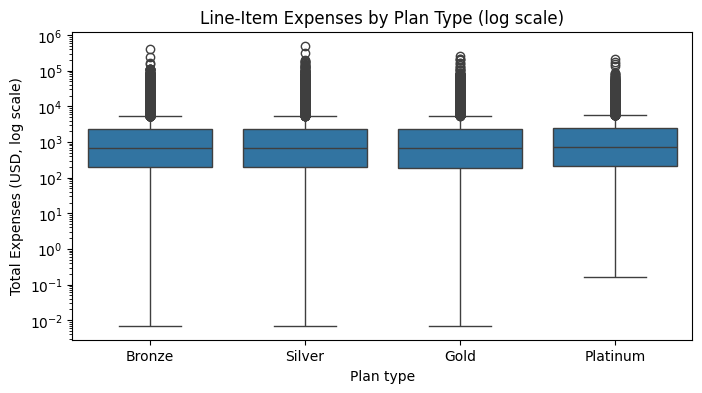

In [24]:
# Boxplot of costs by plan; log scale so medians are visible despite outliers
plt.figure(figsize=(8, 4))
order = ['Bronze', 'Silver', 'Gold', 'Platinum']
sns.boxplot(data=merged[merged['TotalExpenses'] > 0], x='PlanType',
            y='TotalExpenses', order=order)
plt.yscale('log')
plt.title('Line-Item Expenses by Plan Type (log scale)')
plt.xlabel('Plan type')
plt.ylabel('Total Expenses (USD, log scale)')
plt.show()

*TODO — one sentence in your own words interpreting the boxplot (how similar or different the plans' cost distributions look).*